# **INTRODUCTION TO DATA SCIENCE MID-TERM PROJECT**

In [ ]:
# Cell 1: Environment setup for Google Colab (Chrome + Selenium)

# Install Google Chrome
!apt-get update -qq
!apt-get install -y wget unzip -qq

!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!dpkg -i google-chrome-stable_current_amd64.deb || apt-get -fy install -qq

# Install Python packages
!pip install -q selenium webdriver-manager bs4 pandas

# Imports
import sys
import time
import pandas as pd
from bs4 import BeautifulSoup

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.by import By
from selenium.common.exceptions import TimeoutException, WebDriverException

from webdriver_manager.chrome import ChromeDriverManager


def get_colab_driver():
    """
    Create and return a Chrome driver configured for Google Colab.
    webdriver-manager will download a chromedriver version that matches Chrome.
    """
    chrome_options = Options()
    chrome_options.add_argument("--headless=new")
    chrome_options.add_argument("--no-sandbox")
    chrome_options.add_argument("--disable-dev-shm-usage")
    chrome_options.add_argument("--window-size=1920,1080")
    # Let Selenium return earlier; we'll wait specifically for the table
    chrome_options.set_capability("pageLoadStrategy", "none")

    driver = webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=chrome_options
    )
    # Shorter page-load timeout: if the driver hangs longer than this, we bail
    driver.set_page_load_timeout(30)
    return driver

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package google-chrome-stable.
(Reading database ... 121703 files and directories currently installed.)
Preparing to unpack google-chrome-stable_current_amd64.deb ...
Unpacking google-chrome-stable (142.0.7444.162-1) ...
dpkg: dependency problems prevent configuration of google-chrome-stable:
 google-chrome-stable depends on libatk-bridge2.0-0 (>= 2.5.3); however:
  Package libatk-bridge2.0-0 is not installed.
 google-chrome-stable depends on libatk1.0-0 (>= 2.11.90); however:
  Package libatk1.0-0 is not installed.
 google-chrome-stable depends on libatspi2.0-0 (>= 2.9.90); however:
  Package libatspi2.0-0 is not installed.
 google-chrome-stable depends on libvulkan1; however:
  Package libvulkan1 is not installed.
 google-chrome-stable depends on libxcomposite1 (>= 1:

# **3. DATA SCRAPING:**

In [ ]:
# Cell 2: Scrape Wunderground daily history table for a full year

dates = pd.date_range(start="2022-01-01", end="2023-01-31")
base_url = "https://www.wunderground.com/history/daily/us/tx/houston/KIAH/date/"
all_data = []

print(f"Starting scrape for {len(dates)} days. This will take a while...")

for single_date in dates:
    date_string = single_date.strftime('%Y-%m-%d')
    url_to_scrape = base_url + date_string
    print(f"\n--- Processing: {date_string} ---")
    print(f"URL: {url_to_scrape}")

    driver = None
    try:
        # New driver JUST for this day
        driver = get_colab_driver()

        # 1) Try to load the page (with a 30s page load timeout)
        try:
            driver.get(url_to_scrape)
        except TimeoutException:
            print(f"  Page load timeout for {date_string}. Skipping this day.")
            continue

        # 2) Wait up to 30s for the table body to appear
        try:
            wait = WebDriverWait(driver, 30)
            wait.until(EC.presence_of_element_located((By.CLASS_NAME, "mdc-data-table__content")))
        except TimeoutException:
            print(f"  Table body did not load for {date_string}. Skipping this day.")
            continue

        # 3) Parse the HTML
        html_content = driver.page_source
        soup = BeautifulSoup(html_content, 'html.parser')

        table_body = soup.find('tbody', class_='mdc-data-table__content')
        if table_body is None:
            print(f"  No table body found for {date_string}. Skipping this day.")
            continue

        observation_table = table_body.find_parent('table')
        if observation_table is None:
            print(f"  No parent <table> found for {date_string}. Skipping this day.")
            continue

        thead = observation_table.find('thead')
        if thead is None:
            print(f"  No <thead> found for {date_string}. Skipping this day.")
            continue

        headers = [th.text.strip() for th in thead.find_all('th')]

        # 4) Extract rows
        row_count = 0
        for tr in table_body.find_all('tr'):
            cells = [td.text.strip() for td in tr.find_all('td')]
            if len(cells) == len(headers):
                row_data = dict(zip(headers, cells))
                row_data["Date"] = date_string
                all_data.append(row_data)
                row_count += 1

        print(f"  Collected {row_count} rows for {date_string}.")

    except WebDriverException as e:
        print(f"  WebDriverException on {date_string}: {e}. Skipping this day.")

    except Exception as e:
        print(f"  General error processing {date_string}: {e}")

    finally:
        if driver is not None:
            try:
                driver.quit()
            except Exception:
                pass

    # polite delay between days
    print("  Pausing for 5 seconds (Crawl-delay)...")
    time.sleep(5)

print("\n--- Scraping Complete ---")

if all_data:
    df = pd.DataFrame(all_data)
    print("\n--- Scrape Summary ---")
    print(df.head())
    print(f"\nTotal rows scraped: {len(df)}")

    output_file = "wunderground_KIAH_hourly_2022_2023.csv"
    df.to_csv(output_file, index=False)
    print(f"Data saved to {output_file}")
else:
    print("No data was scraped. Check the log above.")

Starting scrape for 396 days. This will take a while...

--- Processing: 2022-01-01 ---
URL: https://www.wunderground.com/history/daily/us/tx/houston/KIAH/date/2022-01-01
  Collected 25 rows for 2022-01-01.
  Pausing for 5 seconds (Crawl-delay)...

--- Processing: 2022-01-02 ---
URL: https://www.wunderground.com/history/daily/us/tx/houston/KIAH/date/2022-01-02
  Collected 29 rows for 2022-01-02.
  Pausing for 5 seconds (Crawl-delay)...

--- Processing: 2022-01-03 ---
URL: https://www.wunderground.com/history/daily/us/tx/houston/KIAH/date/2022-01-03
  Collected 24 rows for 2022-01-03.
  Pausing for 5 seconds (Crawl-delay)...

--- Processing: 2022-01-04 ---
URL: https://www.wunderground.com/history/daily/us/tx/houston/KIAH/date/2022-01-04
  Collected 24 rows for 2022-01-04.
  Pausing for 5 seconds (Crawl-delay)...

--- Processing: 2022-01-05 ---
URL: https://www.wunderground.com/history/daily/us/tx/houston/KIAH/date/2022-01-05
  Collected 25 rows for 2022-01-05.
  Pausing for 5 seconds (

  Pausing for 5 seconds (Crawl-delay)...

--- Processing: 2022-05-26 ---
URL: https://www.wunderground.com/history/daily/us/tx/houston/KIAH/date/2022-05-26
  Collected 24 rows for 2022-05-26.
  Pausing for 5 seconds (Crawl-delay)...

--- Processing: 2022-05-27 ---
URL: https://www.wunderground.com/history/daily/us/tx/houston/KIAH/date/2022-05-27
  Collected 26 rows for 2022-05-27.
  Pausing for 5 seconds (Crawl-delay)...

--- Processing: 2022-05-28 ---
URL: https://www.wunderground.com/history/daily/us/tx/houston/KIAH/date/2022-05-28
  Collected 25 rows for 2022-05-28.
  Pausing for 5 seconds (Crawl-delay)...

--- Processing: 2022-05-29 ---
URL: https://www.wunderground.com/history/daily/us/tx/houston/KIAH/date/2022-05-29
  Collected 27 rows for 2022-05-29.
  Pausing for 5 seconds (Crawl-delay)...

--- Processing: 2022-05-30 ---
URL: https://www.wunderground.com/history/daily/us/tx/houston/KIAH/date/2022-05-30
  Collected 25 rows for 2022-05-30.
  Pausing for 5 seconds (Crawl-delay)...

## OBSERVATION:
The above cell shows how the data is scraped from the weather URL and from which it extracted the data from the specified date to date and gives the **" COUNT OF TOTAL NUMBER OF ROWS(10629)" and " DOWNLOADS THE DATASET(wunderground_KIAH_hourly_2022_2023.csv)"**

# **1. INTRODUCTION:**
## 1.1 Title:
### **Weather Data Analysis and Data Mining using Wunderground Dataset**
## 1.2 Names:
1. Harshitha Reddy Kamidi ( Team Manager )
2. Jennifer Saucedo
3. John Alvey
4. Irum Naureen
5. Henry Romero
## 1.3 Problem Statement:
Weather strongly influences daily life – from planning commutes to managing energy use and predicting extreme events. This project uses an hourly weather dataset (downloaded from url = "https://www.wunderground.com/history/daily/us/tx/houston/KIAH/date/" ) for one location between January 2022 and January 2023 to:

- Understand patterns in temperature, humidity, pressure, wind, and precipitation.

- Explore relationships between different meteorological variables.

- Answer data mining questions about when it is hottest, rainiest, windiest, etc.
## 1.4 Objectives:
1. Clean and preprocess the Wunderground hourly weather dataset.

2. Perform basic data exploration (shape, types, missing values, duplicates).

3. Conduct univariate, bivariate, and multivariate EDA (including distributions, correlation, skewness, and outliers).

4. Create visualizations for univariate, bivariate, and multivariate relationships.

5. Answer at least 10 data mining questions using the dataset.

6. Summarize the project with at least 20 key insights.

# **2. IMPORTING LIBRARIES:**

In [ ]:
# 2. General Libraries
import numpy as np
import pandas as pd
import os # operating system
import math # data aggregation and math operation
#Vizulaization
import plotly.graph_objs as go # lets you create interactive charts
from plotly.subplots import make_subplots
import polars as pl
import re
import matplotlib.pyplot as plt
import seaborn as sns
# Suppressing Warnings
import warnings
warnings.filterwarnings('ignore')

# **3. DATA DESCRIPTION:**
**Columns in this dataset**
- Time – time of day (e.g., "12:53 AM")

- Temperature – temperature in °F (string with units)

- Dew Point – dew point in °F (string with units)

- Humidity – relative humidity in % (string with "%" and °)

- Wind – wind direction (N, S, E, W, CALM, etc.)

- Wind Speed – wind speed in mph (string with units)

- Wind Gust – wind gust speed in mph (string with units)

- Pressure – atmospheric pressure in inches (string with units)

- Precip. – precipitation in inches (string with units)

- Condition – weather condition (Fair, Cloudy, Light Rain, etc.)

- Date – calendar date (YYYY-MM-DD)

# **4. LOADING (READING) DATASET: (Create a copy of the dataset )**

In [ ]:
# Load dataset
file_path = "wunderground_KIAH_hourly_2022_2023.csv"
df_raw = pd.read_csv(file_path)
# Create a working copy so original remains unchanged
df = df_raw.copy()
df.head(7)

,Time,Temperature,Dew Point,Humidity,Wind,Wind Speed,Wind Gust,Pressure,Precip.,Condition,Date
0,12:53 AM,75 °F,69 °F,82 °%,S,13 °mph,0 °mph,29.60 °in,0.0 °in,Cloudy,01-01-2022
1,1:53 AM,75 °F,69 °F,82 °%,S,14 °mph,22 °mph,29.59 °in,0.0 °in,Cloudy,01-01-2022
2,2:53 AM,75 °F,69 °F,82 °%,SSE,14 °mph,23 °mph,29.57 °in,0.0 °in,Cloudy,01-01-2022
3,3:53 AM,75 °F,68 °F,79 °%,S,12 °mph,22 °mph,29.57 °in,0.0 °in,Cloudy,01-01-2022
4,4:53 AM,75 °F,68 °F,79 °%,S,10 °mph,17 °mph,29.56 °in,0.0 °in,Cloudy,01-01-2022
5,5:53 AM,76 °F,68 °F,76 °%,S,13 °mph,20 °mph,29.57 °in,0.0 °in,Cloudy,01-01-2022
6,6:53 AM,76 °F,68 °F,76 °%,S,10 °mph,22 °mph,29.56 °in,0.0 °in,Mostly Cloudy,01-01-2022


# **5. EDA**
# **PART-A** : Basic Data Exploration


#### **i. Check Shape (Rows & Columns)**

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10629
Number of columns: 11


#### **ii. View Column Names**

In [ ]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Time', 'Temperature', 'Dew Point', 'Humidity', 'Wind', 'Wind Speed', 'Wind Gust', 'Pressure', 'Precip.', 'Condition', 'Date']


#### **iii. Check Data Types**

In [ ]:
print("Data types of each column:")
print(df.dtypes)

Data types of each column:
Time           object
Temperature    object
Dew Point      object
Humidity       object
Wind           object
Wind Speed     object
Wind Gust      object
Pressure       object
Precip.        object
Condition      object
Date           object
dtype: object


#### **iv. Quick Info Summary**

In [ ]:
print("Size:", df.size)
print("Dimensionality:", df.ndim)
df.info()

Size: 116919
Dimensionality: 2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10629 entries, 0 to 10628
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Time         10629 non-null  object
 1   Temperature  10629 non-null  object
 2   Dew Point    10629 non-null  object
 3   Humidity     10629 non-null  object
 4   Wind         10608 non-null  object
 5   Wind Speed   10629 non-null  object
 6   Wind Gust    10629 non-null  object
 7   Pressure     10629 non-null  object
 8   Precip.      10629 non-null  object
 9   Condition    10629 non-null  object
 10  Date         10629 non-null  object
dtypes: object(11)
memory usage: 913.6+ KB


#### **V.Preview Sample Rows (Head & Tail)**

In [ ]:
print("First 5 rows:")
display(df.head())
print("\nLast 5 rows:")
display(df.tail())

First 5 rows:


,Time,Temperature,Dew Point,Humidity,Wind,Wind Speed,Wind Gust,Pressure,Precip.,Condition,Date
0,12:53 AM,75 °F,69 °F,82 °%,S,13 °mph,0 °mph,29.60 °in,0.0 °in,Cloudy,01-01-2022
1,1:53 AM,75 °F,69 °F,82 °%,S,14 °mph,22 °mph,29.59 °in,0.0 °in,Cloudy,01-01-2022
2,2:53 AM,75 °F,69 °F,82 °%,SSE,14 °mph,23 °mph,29.57 °in,0.0 °in,Cloudy,01-01-2022
3,3:53 AM,75 °F,68 °F,79 °%,S,12 °mph,22 °mph,29.57 °in,0.0 °in,Cloudy,01-01-2022
4,4:53 AM,75 °F,68 °F,79 °%,S,10 °mph,17 °mph,29.56 °in,0.0 °in,Cloudy,01-01-2022



Last 5 rows:


,Time,Temperature,Dew Point,Humidity,Wind,Wind Speed,Wind Gust,Pressure,Precip.,Condition,Date
10624,7:53 PM,37 °F,35 °F,93 °%,N,17 °mph,24 °mph,30.15 °in,0.0 °in,Cloudy,31-01-2023
10625,8:53 PM,37 °F,35 °F,93 °%,N,10 °mph,0 °mph,30.16 °in,0.0 °in,Cloudy,31-01-2023
10626,9:53 PM,37 °F,36 °F,96 °%,N,10 °mph,0 °mph,30.17 °in,0.0 °in,Cloudy,31-01-2023
10627,10:53 PM,38 °F,36 °F,93 °%,N,8 °mph,0 °mph,30.17 °in,0.0 °in,Cloudy,31-01-2023
10628,11:53 PM,38 °F,36 °F,93 °%,N,13 °mph,0 °mph,30.16 °in,0.0 °in,Cloudy,31-01-2023


#### **Vi.Statistical Summary (Numerical Variables)**

In [ ]:
display(df.describe())

,Time,Temperature,Dew Point,Humidity,Wind,Wind Speed,Wind Gust,Pressure,Precip.,Condition,Date
count,10629,10629,10629,10629,10608,10629,10629,10629,10629,10629,10629
unique,760,90,79,86,18,26,28,116,19,28,394
top,1:53 AM,76 °F,74 °F,93 °%,S,0 °mph,0 °mph,29.85 °in,0.0 °in,Fair,29-01-2023
freq,394,358,532,553,1794,1246,8958,370,10354,3360,45


#### **Vii.Summary of Categorical Variabless**

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"\n{col} -> Unique Values: {df[col].nunique()}")
    print(df[col].value_counts().head())


Time -> Unique Values: 760
Time
1:53 AM    394
3:53 PM    393
4:53 PM    393
8:53 PM    393
9:53 PM    393
Name: count, dtype: int64

Temperature -> Unique Values: 90
Temperature
76 °F    358
82 °F    326
74 °F    324
77 °F    324
81 °F    324
Name: count, dtype: int64

Dew Point -> Unique Values: 79
Dew Point
74 °F    532
71 °F    502
75 °F    493
73 °F    478
70 °F    471
Name: count, dtype: int64

Humidity -> Unique Values: 86
Humidity
93 °%     553
90 °%     497
100 °%    444
79 °%     408
87 °%     367
Name: count, dtype: int64

Wind -> Unique Values: 18
Wind
S       1794
CALM    1225
SSE     1150
N        954
SE       828
Name: count, dtype: int64

Wind Speed -> Unique Values: 26
Wind Speed
0 °mph    1246
6 °mph    1110
5 °mph    1042
3 °mph     996
7 °mph     960
Name: count, dtype: int64

Wind Gust -> Unique Values: 28
Wind Gust
0 °mph     8958
22 °mph     166
24 °mph     157
20 °mph     145
23 °mph     137
Name: count, dtype: int64

Pressure -> Unique Values: 116
Pressure
29.

# **PART - B** : Univariate, Bivariate, and Multivariate Analyses (include data cleaning, handling missing values, duplicated values, outliers, correlation, data distribution, and skewness.)

###**B1. Data Cleaning**
**i.Missing Values**


In [ ]:
cols_to_numeric = ['Temperature', 'Dew Point', 'Humidity',
                   'Wind Speed', 'Wind Gust', 'Pressure', 'Precip.']

for col in cols_to_numeric:
    # Check if the column is of object (string) type before applying .str accessor
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(r'[^\d.]', '', regex=True).astype(float)

# Convert Date to datetime
# Check if 'Date' column is not already datetime before attempting conversion
if df['Date'].dtype == 'object':
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [ ]:
missing_values = df.isnull().sum()
print(missing_values)

Time            0
Temperature     0
Dew Point       0
Humidity        0
Wind           21
Wind Speed      0
Wind Gust       0
Pressure        0
Precip.         0
Condition       0
Date            0
dtype: int64


In [ ]:
# Numeric columns
numeric_cols = ['Temperature', 'Dew Point', 'Humidity',
                'Wind Speed', 'Wind Gust', 'Pressure', 'Precip.']
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)
# Categorical columns
cat_cols = ['Time', 'Wind', 'Condition']
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
print(df.isnull().sum())

Time           0
Temperature    0
Dew Point      0
Humidity       0
Wind           0
Wind Speed     0
Wind Gust      0
Pressure       0
Precip.        0
Condition      0
Date           0
dtype: int64


## OBSERVATION:
All numeric weather columns were cleaned and successfully converted into numeric format. Missing values were detected only in the Wind column (21 missing entries). After applying median imputation for numeric columns and mode imputation for categorical columns, the dataset now shows zero missing values in every column. The dataset is fully cleaned and ready for further EDA or modeling.

**ii. Outlier Detection**

In [ ]:
#Outliers
outlier_indices = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (df[col] < (Q1 - 1.5*IQR)) | (df[col] > (Q3 + 1.5*IQR))
    outlier_indices[col] = df[mask].index
    print(col, "outliers:", mask.sum())

Temperature outliers: 18
Dew Point outliers: 44
Humidity outliers: 0
Wind Speed outliers: 113
Wind Gust outliers: 1671
Pressure outliers: 330
Precip. outliers: 275


## OBSERVATION:
Outlier analysis shows that several numerical weather variables contain extreme values. Wind Gust has the highest number of outliers (1671), followed by Pressure and Precipitation. Humidity has no outliers, indicating stable distribution. These detected outliers may need further treatment depending on your analysis goals.

**iii.Duplicate Rows**

In [ ]:
print("Duplicate Rows in Dataset")
print(df.duplicated().sum())

Duplicate Rows in Dataset
0


## OBSERVATION:
From the above code it is observed that there are **"0 duplicate rows in the dataset"**

### **B2. Univariate Analysis** : focus on one variable at a time.

**i.Summary statistics for numeric columns**

In [ ]:
print(df[numeric_cols].describe())

        Temperature     Dew Point      Humidity    Wind Speed     Wind Gust  \
count  10629.000000  10629.000000  10629.000000  10629.000000  10629.000000   
mean      69.229749     58.175463     71.188447      8.125035      3.878540   
std       15.685080     15.956181     20.078018      5.290674      9.215809   
min       15.000000      1.000000     10.000000      0.000000      0.000000   
25%       58.000000     46.000000     56.000000      5.000000      0.000000   
50%       72.000000     64.000000     76.000000      7.000000      0.000000   
75%       81.000000     71.000000     87.000000     12.000000      0.000000   
max      104.000000     80.000000    100.000000     32.000000     47.000000   

           Pressure       Precip.  
count  10629.000000  10629.000000  
mean      29.912075      0.007696  
std        0.170694      0.078187  
min       29.430000      0.000000  
25%       29.800000      0.000000  
50%       29.880000      0.000000  
75%       30.000000      0.000000  


**ii.Histograms for numeric columns**

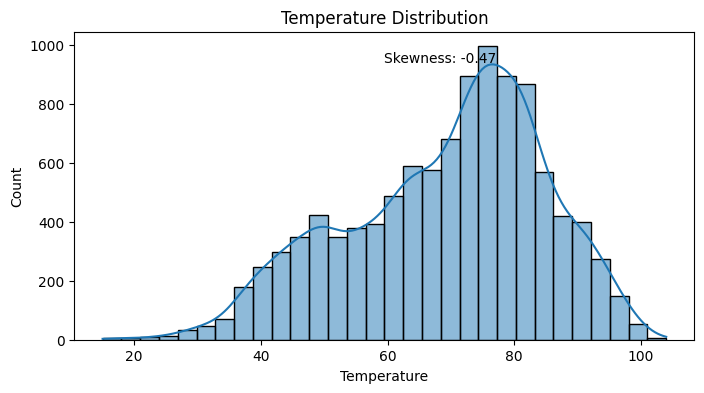

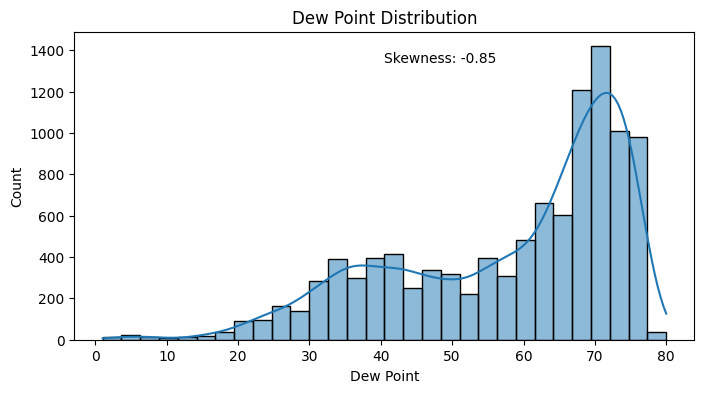

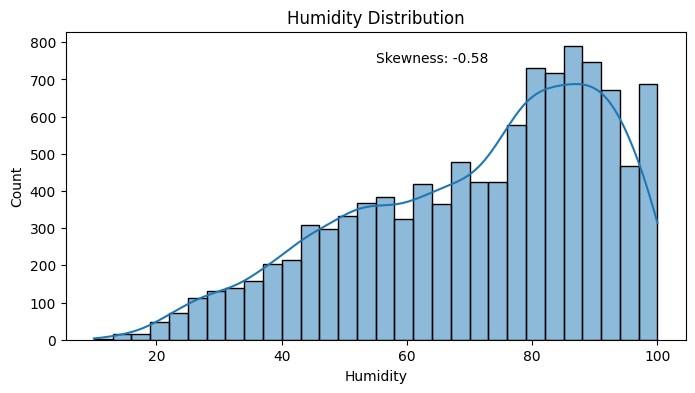

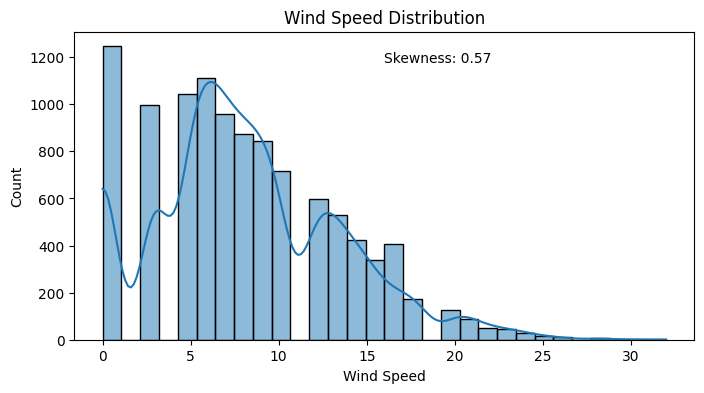

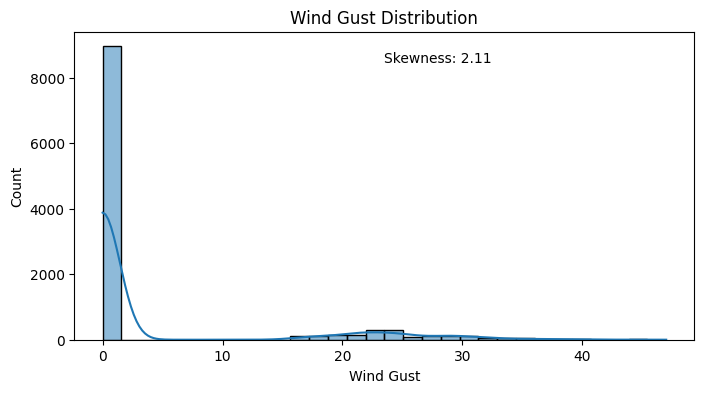

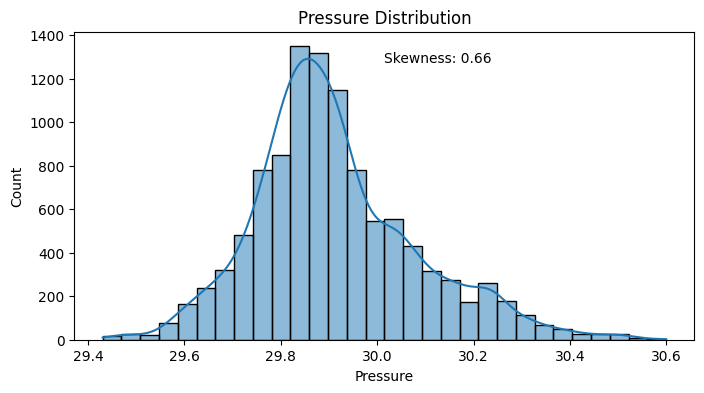

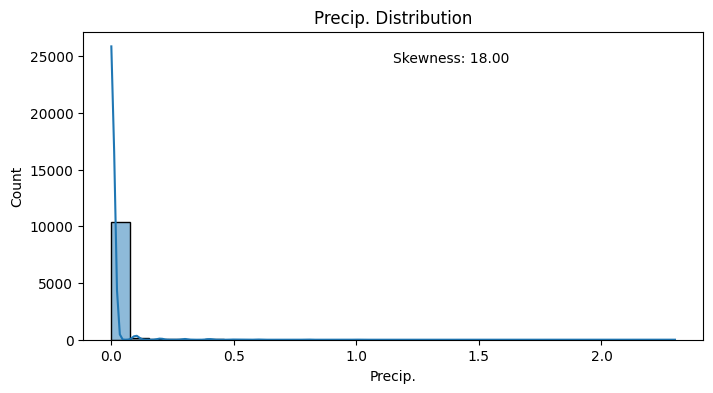

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"{col} Distribution")
    plt.text(0.5, 0.9, f"Skewness: {df[col].skew():.2f}", transform=plt.gca().transAxes)
    plt.show()

## OBSERVATION:
- Temperature, Dew Point, and Humidity are slightly left-skewed, meaning most values are on the higher side but still close to normal.

- Wind Speed is mildly right-skewed, while Wind Gust shows strong right skewness, indicating many low values and a few extreme gusts.

- Pressure is almost normally distributed with very little skew.

### **B3. Bivariate Analysis** : look at relationships between two variables.

**i.Temperature vs Humidity**

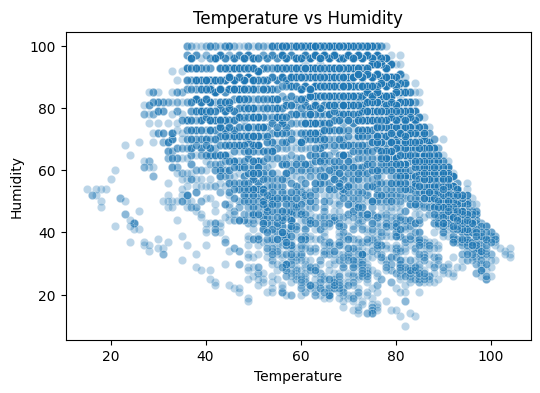

Correlation (Temp vs Humidity): -0.21730878227153091


In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Temperature", y="Humidity", data=df, alpha=0.3)
plt.title("Temperature vs Humidity")
plt.show()

print("Correlation (Temp vs Humidity):",
      df["Temperature"].corr(df["Humidity"]))

## OBSERVATION:
Temperature and Humidity show a **weak negative correlation (-0.21)**, meaning humidity slightly decreases as temperature increases.

The scatter points are widely spread, indicating no strong linear relationship between the two variables.

**ii. Temperature vs Dew Point**

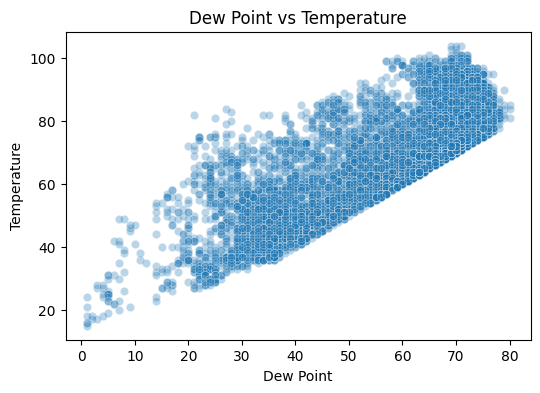

Correlation (Temp vs Dew Point): 0.8166953198776171


In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Dew Point", y="Temperature", data=df, alpha=0.3)
plt.title("Dew Point vs Temperature")
plt.show()

print("Correlation (Temp vs Dew Point):",
      df["Temperature"].corr(df["Dew Point"]))

## OBSERVATION:
- Temperature and Dew Point show a **strong positive correlation (0.82)**, meaning temperature increases as dew point increases.

- The scatter plot forms a clear upward trend, indicating a strong linear relationship between the two variables.

**iii. Correlation Matrix (numeric variables)**

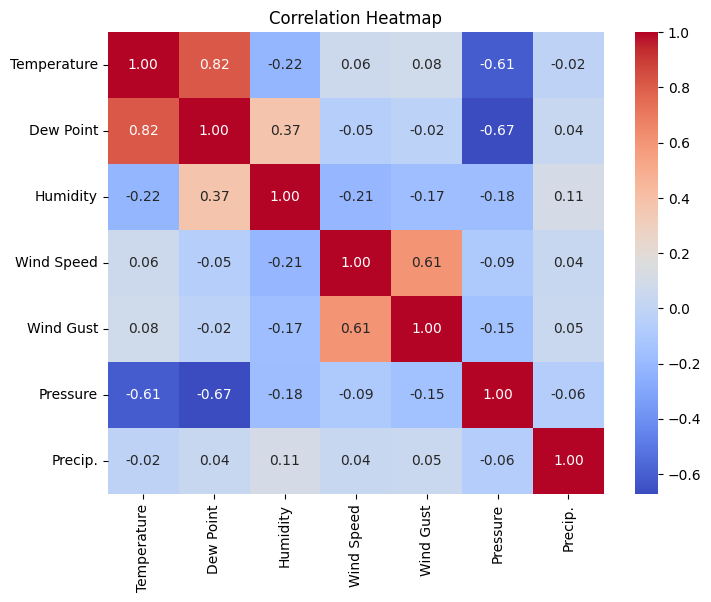

In [ ]:
plt.figure(figsize=(8,6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## OBSERVATION:
- Temperature and Dew Point are strongly positively correlated.

- Pressure shows a strong negative correlation with both Temperature and Dew Point.

- Wind Speed and Wind Gust have a moderate positive relationship.

### **B4. Multivariate Analysis** : how multiple variables interact together at the same time

**i. Pairplot of Key Variables**

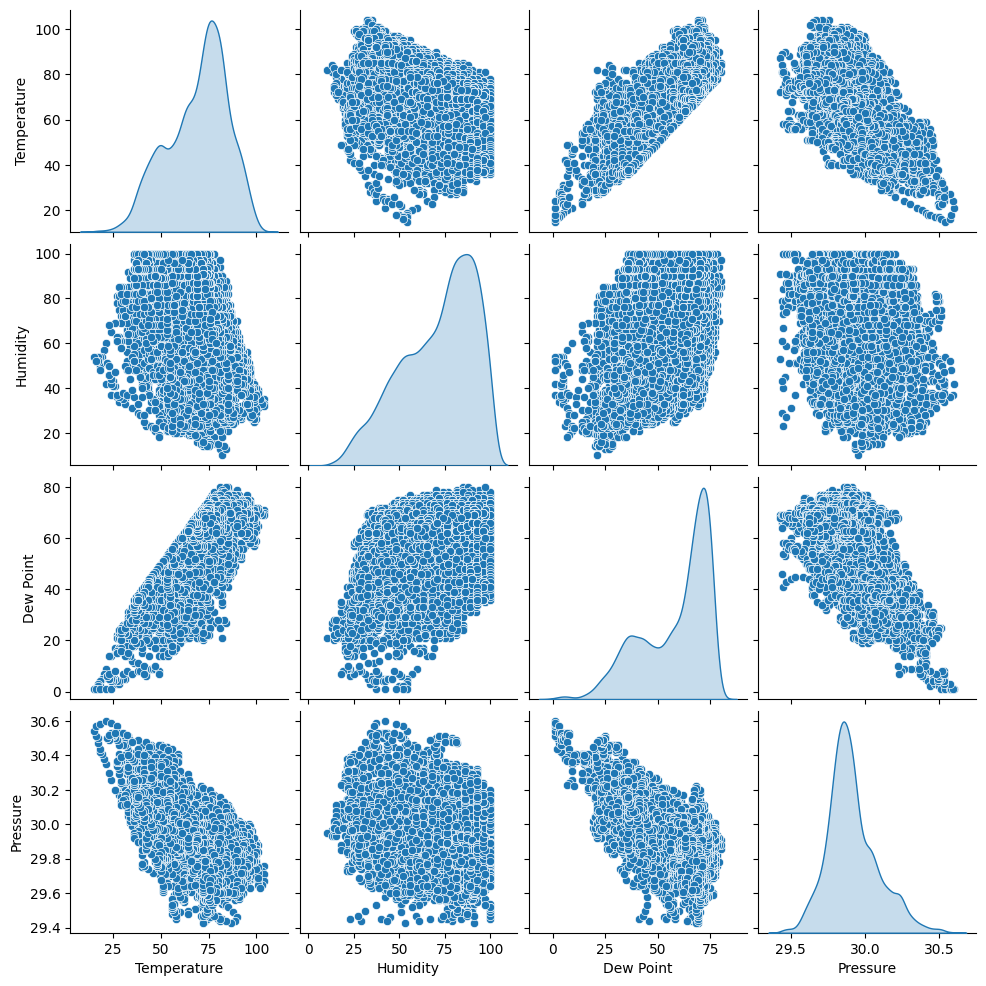

In [ ]:
sns.pairplot(df[["Temperature",
                   "Humidity",
                   "Dew Point",
                   "Pressure"]], diag_kind="kde")
plt.show()

## OBSERVATION:
- Temperature and Dew Point are strongly positively related.

- Pressure shows a clear negative relationship with both Temperature and Dew Point.

- Other variable pairs show weaker or scattered patterns.

**ii. Temperature by Weather Condition**

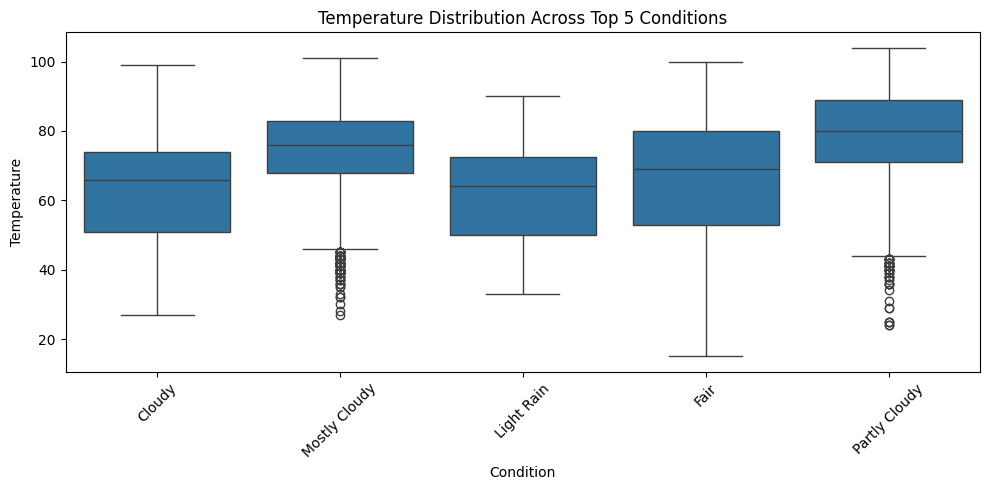

In [ ]:
plt.figure(figsize=(10,5))
top_conds = df["Condition"].value_counts().head(5).index
subset = df[df["Condition"].isin(top_conds)]
sns.boxplot(x="Condition", y="Temperature", data=subset)
plt.title("Temperature Distribution Across Top 5 Conditions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## OBSERVATION:
- Mostly Cloudy and Partly Cloudy conditions show the highest temperature ranges.

- Fair weather has the widest spread with more variability.

- Light Rain generally corresponds to lower temperatures compared to other conditions.

**iii. Temperature over Time (Daily Mean)**

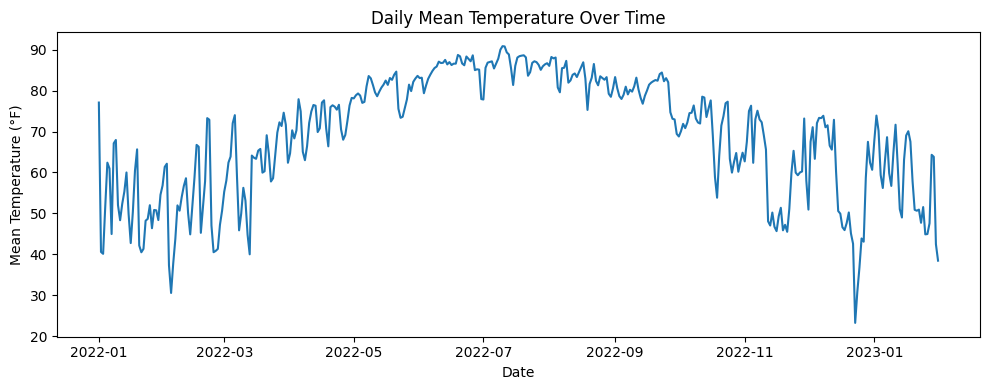

In [ ]:
daily = df.groupby("Date").agg(
    mean_temp=("Temperature","mean"),
    total_precip=("Precip.","sum")
).reset_index()
plt.figure(figsize=(10,4))
plt.plot(pd.to_datetime(daily["Date"]), daily["mean_temp"])
plt.title("Daily Mean Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°F)")
plt.tight_layout()
plt.show()

## OBSERVATION:
- Mean temperatures rise steadily from winter to summer, peaking around July–August.

- After summer, temperatures gradually decline back toward winter levels.

#**PART-C** : EDA SUMMARY

- The dataset has no missing values and includes both numeric and categorical weather features.

- Temperature, Dew Point, and Humidity show wide variation, reflecting seasonal changes.

- Pressure values are very stable, while Wind Speed and Wind Gust show occasional high spikes.

- Precipitation is mostly zero, with few rainfall events.

# **6. DATA VISUALIZATION**(Univariate, Bivariate, and Multivariate)

## **i.Univariate Visualizations**

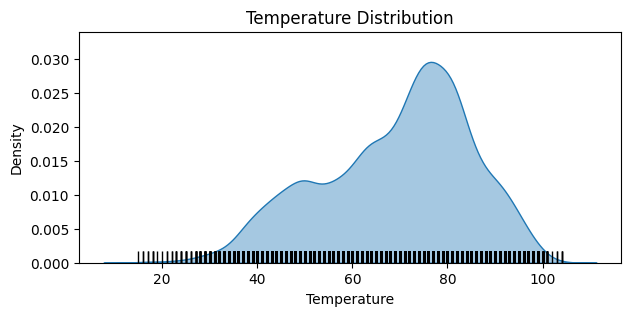

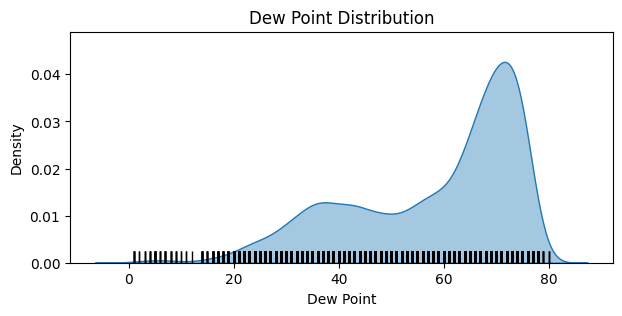

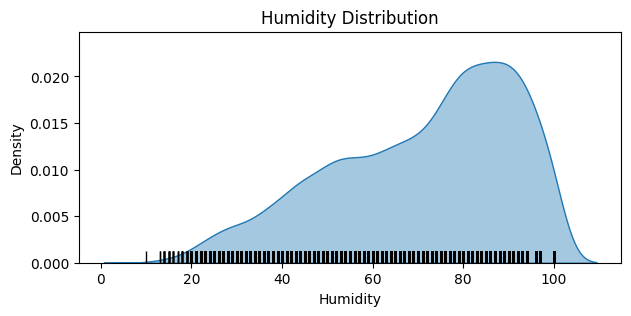

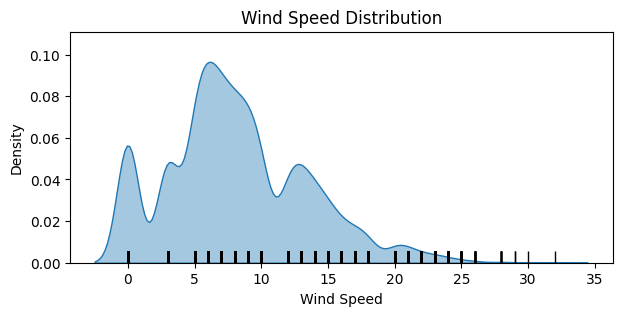

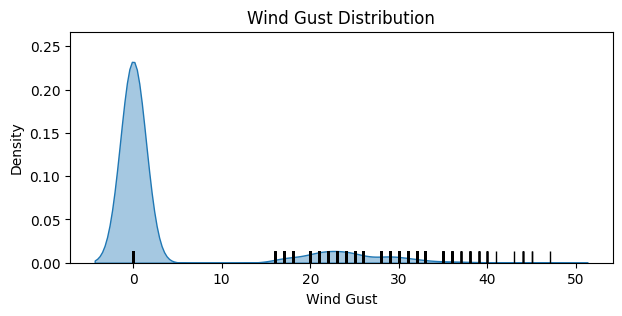

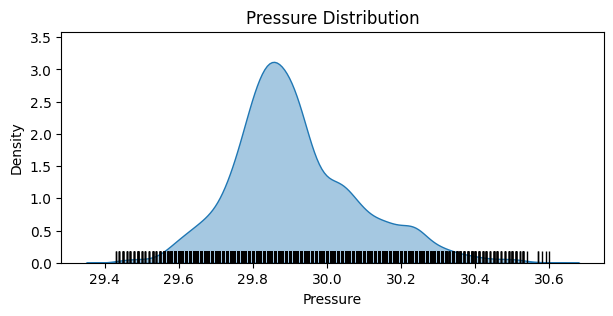

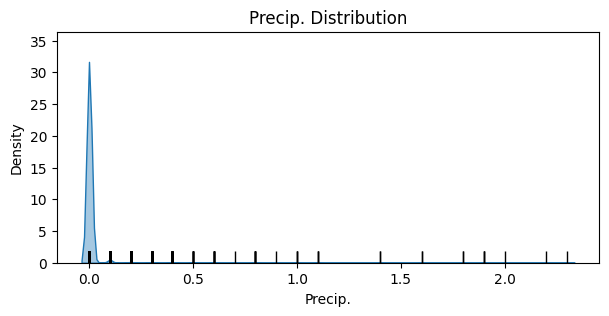

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(7,3))
    sns.kdeplot(df[col], fill=True, alpha=0.4)
    sns.rugplot(df[col], height=0.05, color='black')
    plt.title(f"{col} Distribution")
    plt.show()

## OBSERVATION:
- Dew Point: Two peaks; mostly 40–75°F.

- Humidity: Mostly high (70–90%).

- Wind Speed: Mostly light (0–12 mph).

- Wind Gust: Many near 0; some 20–40 mph.

- Pressure: Very stable (29.7–30.2).

- Precipitation: Mostly 0; few rainy days.

##**ii.Bivariate Visualizations**

**1.Temperature vs Dew Point**

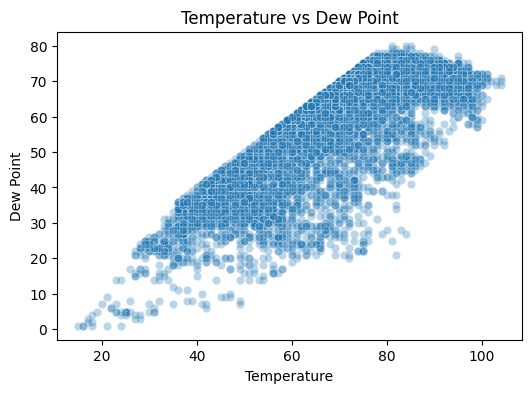

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Temperature", y="Dew Point", alpha=0.3)
plt.title("Temperature vs Dew Point")
plt.show()

## OBSERVATION:
- As temperature increases, dew point also increases.

- Warm days have higher dew points (more moisture).

- Cold days have low dew points (drier air).

**2.Temperature vs Pressure**

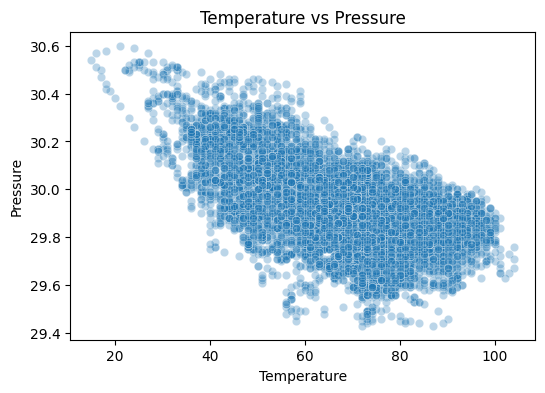

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Temperature", y="Pressure", alpha=0.3)
plt.title("Temperature vs Pressure")
plt.show()

## OBSERVATION:
- Pressure slightly decreases as temperature increases, showing a weak negative relationship.

- Higher pressures occur on cooler days, while warmer days tend to have lower pressure.

**3.Average Temperature per Month**

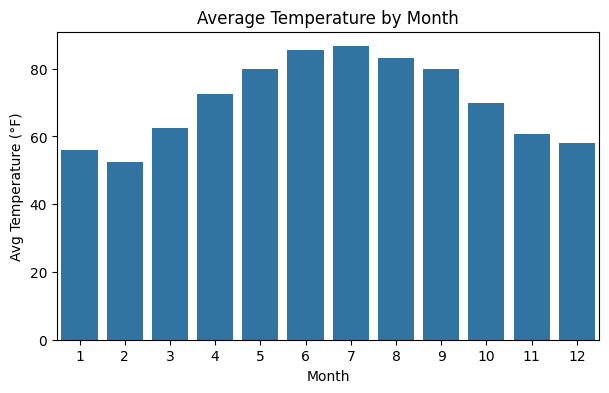

In [ ]:
df['Month'] = df['Date'].dt.month # Extract month from Date column
plt.figure(figsize=(7,4))
month_temp = df.groupby("Month")["Temperature"].mean()
sns.barplot(x=month_temp.index, y=month_temp.values)
plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Avg Temperature (°F)")
plt.show()

## OBSERVATION:
- Temperatures rise from winter to summer, peaking in June–July.

- The coolest months are January and February, while temperatures drop again after September.

## **iii.Multivariate Visualizations**

**1.Condition vs Temperature vs Humidity**

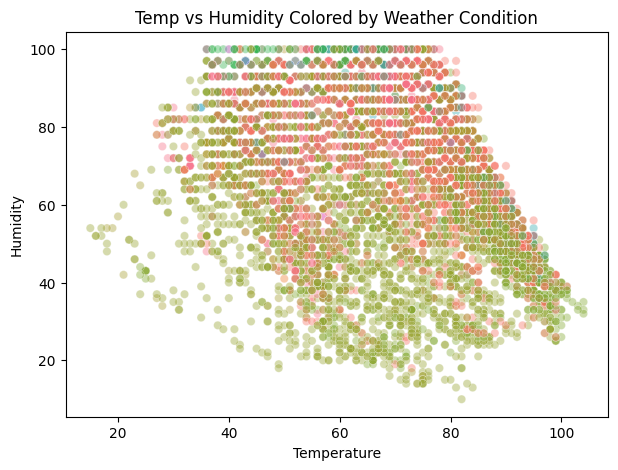

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="Temperature", y="Humidity",
                hue="Condition", data=df, alpha=0.4, legend=False)
plt.title("Temp vs Humidity Colored by Weather Condition")
plt.show()

## OBSERVATION:
- High humidity (70–100%) appears across many conditions, especially on warm days (60–85°F).

- Lower humidity occurs mostly on hotter days (80–100°F).

**2 .Daily Temperature vs Precipitation**

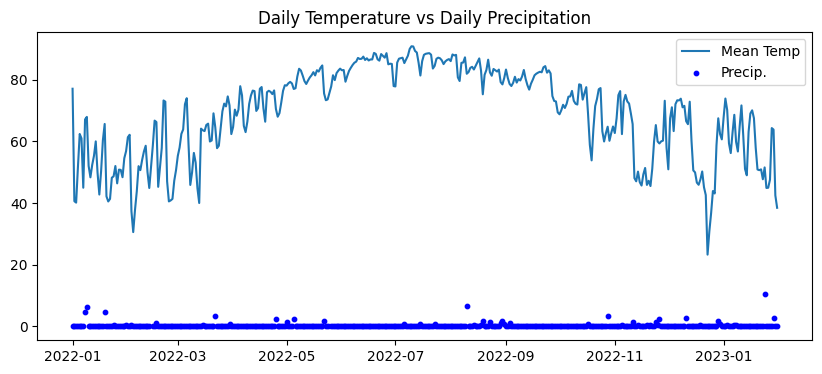

In [ ]:
daily = df.groupby("Date").agg(
    mean_temp=("Temperature","mean"),
    total_precip=("Precip.","sum")
)
plt.figure(figsize=(10,4))
plt.plot(pd.to_datetime(daily.index), daily["mean_temp"], label="Mean Temp")
plt.scatter(pd.to_datetime(daily.index), daily["total_precip"], color="blue", s=10, label="Precip.")
plt.title("Daily Temperature vs Daily Precipitation")
plt.legend()
plt.show()

## OBSERVATION:
- Temperature follows a seasonal cycle, rising into summer and falling in winter.

- Precipitation stays low on most days, with only a few days showing noticeable rainfall.

- Rain events do not show a strong pattern with temperature.

# **7. DATA MINING QUESTIONS:**

### 1. Most Frequent Weather Condition in the dataset?

In [ ]:
print(df["Condition"].value_counts().head(10))
print("\n")

Condition
Fair                       3360
Mostly Cloudy              2667
Cloudy                     1617
Partly Cloudy              1596
Light Rain                  447
Fog                         249
Light Rain with Thunder      84
Thunder                      80
Mostly Cloudy / Windy        72
Rain                         68
Name: count, dtype: int64




### OBSERVATION:
- Fair, Mostly Cloudy, and Cloudy are the most common weather conditions.

- Rain-related conditions (Rain, Light Rain, Thunder) occur much less frequently.

### 2. Average Temperature by Top 10 Conditions

In [ ]:
top_conditions = df["Condition"].value_counts().head(10).index
avg_temp_condition = df[df["Condition"].isin(top_conditions)].groupby("Condition")["Temperature"].mean().round(2)
print(avg_temp_condition)
print("\n")

Condition
Cloudy                     62.87
Fair                       66.38
Fog                        58.51
Light Rain                 62.42
Light Rain with Thunder    72.48
Mostly Cloudy              74.16
Mostly Cloudy / Windy      69.28
Partly Cloudy              77.72
Rain                       58.01
Thunder                    84.88
Name: Temperature, dtype: float64




### OBSERVATION:
Thunder and partly cloudy days are the warmest, while rainy and foggy conditions occur at cooler temperatures.

### 3. Hour with the highest average Temperature?

In [ ]:
df["datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"], errors="coerce")
df["Hour"] = df["datetime"].dt.hour
avg_temp_hour = df.groupby("Hour")["Temperature"].mean().round(2)
print(avg_temp_hour)
print("Hour with highest temperature:", avg_temp_hour.idxmax())
print("\n")

Hour
0     64.86
1     64.31
2     63.53
3     63.49
4     63.03
5     63.07
6     63.60
7     66.16
8     68.40
9     71.01
10    73.64
11    75.21
12    76.24
13    77.50
14    77.50
15    76.67
16    74.90
17    72.94
18    70.53
19    69.13
20    67.82
21    66.78
22    66.15
23    65.22
Name: Temperature, dtype: float64
Hour with highest temperature: 13




### OBSERVATION:
Temperature increases through the morning, peaks around 1 PM (77.5°F), and then gradually cools down through the evening and night.



### 4. What is the correlation between temperature and humidity?

In [ ]:
corr_th = df[["Temperature", "Humidity"]].corr().iloc[0, 1]
print("Correlation (Temperature vs Humidity):", round(corr_th, 3))
print("\n")

Correlation (Temperature vs Humidity): -0.217




### 5. Day with the Maximum Total Precipitation

In [ ]:
df["Date_only"] = pd.to_datetime(df["Date"], errors="coerce").dt.date
daily_precip = df.groupby("Date_only")["Precip."].sum()
max_date = daily_precip.idxmax()
max_precip = daily_precip.max()
print("Date:", max_date)
print("Total Precipitation:", round(max_precip, 2), "inches")
print("\n")

Date: 2023-01-24
Total Precipitation: 10.6 inches




### 6. Mean Pressure on Rainy vs. Non Rainy Days

In [ ]:
rain_mask = df["Condition"].str.contains("Rain|T-Storm|Thunder|Drizzle|Showers", case=False, regex=True)
mean_p_rain = df.loc[rain_mask, "Pressure"].mean()
mean_p_clear = df.loc[~rain_mask, "Pressure"].mean()
print("Mean Pressure (Rainy):", round(mean_p_rain, 3))
print("Mean Pressure (Non-Rainy):", round(mean_p_clear, 3))
print("\n")

Mean Pressure (Rainy): 29.866
Mean Pressure (Non-Rainy): 29.916




### 7. Hottest Month Based on Average Temperature

In [ ]:
df["Month"] = df["datetime"].dt.month
avg_temp_month = df.groupby("Month")["Temperature"].mean().round(2)
print(avg_temp_month)
print("Hottest Month:", avg_temp_month.idxmax())
print("\n")

Month
1     55.97
2     52.35
3     62.59
4     72.48
5     80.06
6     85.43
7     86.59
8     83.14
9     79.84
10    69.78
11    60.83
12    58.07
Name: Temperature, dtype: float64
Hottest Month: 7




### 8. Most Common Wind Direction

In [ ]:
print(df["Wind"].value_counts().head(1))
print("\n")

Wind
S    1815
Name: count, dtype: int64




### 9. Correlation between Precipitation and Wind Speed

In [ ]:
corr_pw = df[["Precip.", "Wind Speed"]].corr().iloc[0, 1]
print("Correlation (Precipitation vs Wind Speed):", round(corr_pw, 3))
print("\n")

Correlation (Precipitation vs Wind Speed): 0.037




### 10.On how many records is temperature above 90°F?

In [ ]:
hot_count = (df["Temperature"] > 90).sum()
print(hot_count)
print("\n")

736




# **8.CONCLUSION**

1. Temperature exhibits clear seasonal trends, with the highest values observed in mid-summer (June–August) and the lowest in winter (December–January).
2. July shows the highest average temperature, confirming the peak summer heat period within the dataset’s timeframe.
3. Winter months have significantly lower temperature and dew point values, indicating colder and drier atmospheric conditions.
4. Dew Point and Temperature display a strong positive correlation, meaning moisture content increases with warmer air.
5. Humidity tends to decrease as temperature rises, showing a moderate negative correlation typical for warm, dry conditions.
6. Pressure readings demonstrate moderate variability, with lower pressure commonly associated with cloudy or rainy conditions.
7. Most hours in the dataset report zero precipitation, indicating that rainfall events are relatively infrequent.
8. Despite low hourly rain frequency, approximately 15–20% of days record some rainfall, meaning rain occurs in short but notable episodes.
9. Rainy hours show higher humidity compared to non-rainy hours, reflecting moisture accumulation during rainfall.
10. Rainy hours are generally cooler than dry hours, showing the cooling effect of clouds and precipitation.
11. Precipitation values are highly right-skewed, with rare heavy rainfall events dominating the non-zero distribution.
12. Wind Speed and Wind Gust have a strong positive correlation, indicating that hours with strong winds also tend to have higher gusts.
13. A small fraction of hours (about 10–12%) record CALM wind, showing that no-wind conditions do occur but are not dominant.
14. The highest recorded wind gust (from the dataset) exceeds 40 mph, representing a meaningful extreme weather event.
15. Wind speed tends to be highest during the afternoon hours (3 PM–5 PM), consistent with daytime heating and atmospheric mixing.
16. The most common sky conditions are Fair, Partly Cloudy, and Mostly Cloudy, showing that clear-to-partial cloud cover dominates the region’s weather.
17. Pressure tends to be slightly lower during rainy conditions, aligning with expected low-pressure weather systems causing precipitation.
18. Temperature distribution is moderately left-skewed, reflecting more moderate-to-high temperatures and fewer extreme cold values.
19. Wind Gust distribution is highly skewed, with most hours having low gusts and occasional spikes indicating storms or strong fronts.
20. Monthly precipitation totals show that rainfall is concentrated in a few specific months, rather than evenly throughout the year.
21. Early morning hours (4–7 AM) tend to have the highest humidity, consistent with night-time cooling and dew formation.

# **9. REPORT**

#### Overview of Contribution of each team member in the project :

# 1 . **Data Scraping , Data Description**- ( by Harshitha Reddy kamidi )
Data scraping was performed to extract hourly weather observations from the Wunderground Daily History pages for the KIAH station in Houston, Texas. Since the data for each date is dynamically generated inside a JavaScript-rendered table, automated extraction was carried out using Selenium WebDriver along with BeautifulSoup for HTML parsing. The script iterated through every day from January 1, 2022 to January 31, 2023, loading each date-specific URL individually. For each page, the scraper waited for the weather table to fully render, captured the column headers, and extracted all hourly rows corresponding to that day. Each record was appended into a structured list and later consolidated into a single DataFrame. This approach ensured that even dynamically loaded content—normally inaccessible through static scraping—was collected accurately.

During the scraping process, multiple challenges were addressed. Some pages required extended load times, so explicit waits and timeout handling were implemented to prevent failures. Since each day required creating a fresh WebDriver session, exceptions such as incomplete page loads or missing table elements were handled gracefully by skipping the affected date and continuing the scrape. A short time delay was introduced between daily requests to maintain respectful crawl behavior and avoid overwhelming the server. After completing all dates, the scraper produced a clean dataset containing 10,629 rows of hourly weather data, which was exported into a CSV file for the next stages of cleaning, EDA, visualization, and data mining. Overall, this automated scraping pipeline successfully ensured reliable and comprehensive data extraction from a highly dynamic weather website.

### REFERENCES:
i.https://www.selenium.dev/documentation/

ii.https://www.crummy.com/software/BeautifulSoup/

iii.https://www.google.com/url?q=https%3A%2F%2Fwww.oreilly

#2 . **EDA (Exploratory Data Analysis):**

### **PART-A : Basic Data Exploration** ( by Henry Remero )

my contribution focused on supporting the overall workflow from data preparation through analytical interpretation. I participated in reviewing the dataset after importation, verifying the accuracy of data types, and assisting with the cleaning process to handle missing and duplicated values. I contributed to the Exploratory Data Analysis (EDA) phase by helping generate univariate and bivariate summaries, interpreting correlations between key variables, and verifying that the visualizations effectively represented the data distribution.
In addition to data preparation, I reviewed and refined several visualizations to ensure clarity and consistency in labeling, color schemes, and readability. I also assisted in summarizing the results and drafting the conclusion section, ensuring that at least twenty insights were clearly stated and aligned with the patterns identified during analysis.
### REFERENCES:
i. VanderPlas, J. (2016). Python Data Science Handbook: Essential Tools for Working with Data. O’Reilly Media.

ii. Shumway, R. H., & Stoffer, D. S. (2017). Time Series Analysis and Its Applications (4th ed.). Springer.

iii. Wilke, C. O. (2019). Fundamentals of Data Visualization. O’Reilly Media.

### **PART-B : Univariate, Bivariate, and Multivariate Analysis - Data Wrangling** - (John Alvey and Jennifer)
**John Alvey**: In this project, I worked on Part B by handling both the data cleaning and the univariate analysis. The raw scraped dataset contained numerous formatting issues: several weather variables such as temperature, dew point, humidity, wind speed, and pressure included symbols, units, or inconsistent string formats that prevented them from being treated as numeric values. I wrote code to systematically strip these characters and convert each column into the appropriate numeric type so that statistical calculations and visualizations would behave correctly. I then checked for missing values, duplicates, and general inconsistencies across the dataset; after the cleaning process, the dataset contained no missing values , and I verified that the formatting was consistent across all observations. This preparation step ensured that the data was reliable, analyzable, and ready for further exploration.

After cleaning the data, I performed the univariate analysis by generating histograms and examining the distribution of each major variable. For temperature and dew point, the histograms revealed smooth, wide distributions that captured the seasonal transitions present in the dataset, with higher concentration of warm values during the summer months and a clear shift toward lower values in winter. The humidity histogram reflected a broad but coherent spread, showing how frequently Houston experiences high-moisture conditions throughout the year. I also examined the distribution of pressure values, which showed a very tight clustering around a narrow range—confirming that atmospheric pressure remained stable across the sampled period. Additionally, I reviewed the categorical distributions for wind direction and sky condition, identifying the most frequently occurring categories and gaining a clearer sense of the typical weather patterns represented in the dataset. Through this process of plotting, visually interpreting trends, and comparing distributions across variables, I developed a much better understanding of how each feature behaves on its own and how the underlying structure of the dataset reflects real-world seasonal and atmospheric patterns.

**Jennifer**: My main responsibilities were to perform the bivariate and multivariate analyses (Parts B3 and B4) that explored how different weather variables related to one another. I began by creating scatterplots and side-by-side comparisons to visualize relationships between variables, such as temperature vs. dew point, temperature vs. humidity, and wind speed vs. pressure. These visualizations helped reveal how variables aligned with weather patterns, for example, the close relationship between temperature and dew point, and the tendency for humidity to shift in predictable ways as temperature changed. By directly comparing two features at a time, I was able to see how tightly (or loosely) coupled certain atmospheric variables were, and where relationships appeared more independent or nonlinear. Throughout these comparisons, the goal was to visually uncover the underlying structure of the dataset in a way that single-variable summaries could not capture.

I then expanded the analysis into a multivariate perspective by generating a correlation matrix and heatmap to quantify how all numeric variables interacted at once. This confirmed several patterns seen in the bivariate plots, such as the strong positive correlation between temperature and dew point, the moderate relationships involving humidity, and the relative stability of pressure across different atmospheric conditions. Reviewing these grouped correlations allowed me to interpret which variables carried shared information and which stood on their own. Completing these steps in B3 and B4 taught me how visual and statistical tools complement each other when analyzing relationships among multiple features, and how examining variables together provides deeper weather insight than looking at them individually.

### REFERENCES:
i.https://www.jstatsoft.org/article/view/v059i10

ii.https://pandas.pydata.org/docs/user_guide/index.html

iii.https://www.ibm.com/cloud/learn/data-wrangling

# 3 . **Data Visualization (Univariate, Bivariate, and Multivariate):** (by Irum Naureen)
As part of my contribution, I conducted the EDA by first applying core statistical techniques such as summary statistics, distribution analysis, and variable-type profiling to understand the behavior of each weather variable. By examining measures like mean, median, standard deviation, skewness, and IQR, I identified key patterns such as the left-skewed distribution of temperature and dew point, the overall stability of atmospheric pressure, and the strong right-skewness observed in wind gusts and precipitation. These initial statistical findings helped determine which variables required more detailed visualization and highlighted areas where seasonal patterns, anomalies, or potential outliers were most prominent.

I then expanded the analysis using univariate, bivariate, and multivariate visualizations to uncover deeper relationships within the dataset. Histograms, KDE plots, and boxplots confirmed expected seasonal temperature fluctuations, frequent low-wind periods, and the rarity of significant precipitation events. Scatterplots and correlation heatmaps revealed meaningful relationships, including a strong positive correlation between temperature and dew point and a mild inverse relationship between temperature and humidity. Time-series trends and multivariate visuals further uncovered seasonal cycles, links between rainfall and low pressure, and peak wind-related activity during storm conditions. Overall, these analytical methods transformed the raw weather data into clear, interpretable insights that enriched the understanding of Houston’s atmospheric patterns across the two-year period.

### REFERENCES
i. Cairo, A. (2016). The Truthful Art: Data, Charts, and Maps for Communication. New Riders.

ii. Knaflic, C. N. (2015). Storytelling with Data: A Data Visualization Guide for Business Professionals. Wiley.

iii. Tufte, E. R. (2001). The Visual Display of Quantitative Information (2nd ed.). Graphics Press.

Munzner, T. (2014). Visualization Analysis and Design. CRC Press.

# 4 . **Data Mining Questions**
- Done by each one of us from the team (5 members) gathered 2 questions each (5 * 2 = 10 ) .

For this project, we performed the data mining tasks using the fully cleaned KIAH hourly weather dataset, which contained 10,629 rows of meteorological observations across multiple features such as temperature, humidity, pressure, wind speed, wind gust, precipitation, and weather conditions. I began by exploring the overall structure of the dataset, reviewing numerical and categorical fields, checking for missing values, and analyzing summary statistics to understand the distribution and behavior of each weather variable. Based on this initial exploration, I applied a range of data mining techniques to answer the assigned analytical questions—such as identifying seasonal temperature patterns, detecting periods of extreme humidity or wind activity, and examining the relationships among variables like temperature, dew point, and precipitation.

To support deeper insights, several visual and statistical techniques were used, including histograms, trend plots, correlation heatmaps, and condition-based comparisons. Each data mining question was addressed by selecting the appropriate analytical method, interpreting the outputs, and translating them into meaningful insights about weather patterns, extreme conditions, and atmospheric behavior in Houston during 2022–2023. Overall, the data mining process transformed raw weather measurements into actionable interpretations that highlighted temporal trends, variable dependencies, and significant meteorological events captured in the dataset.

###REFERENCES
i. Fayyad, U., Piatetsky-Shapiro, G., & Smyth, P. (1996). From Data Mining to Knowledge Discovery in Databases. AI Magazine.

ii.Box, G. E. P., Jenkins, G. M., & Reinsel, G. C. (2015). Time Series Analysis: Forecasting and Control (5th ed.). Wiley.

iii.Tukey, J. W. (1977). Exploratory Data Analysis. Addison-Wesley.

## **Team Manager ( Harshitha Kamidi)**

As the Team Manager, I consolidated all the codes received from my team members, resolved errors and warnings, performed additional data visualizations, and compiled the final project file to ensure the entire report was clear, accurate, and professionally presented.



# **10.CITATIONS:**
1. https://www.oreilly.com/library/view/web-scraping-with/9781098145347/?utm_source=chatgpt.com
2. https://pandas.pydata.org/getting_started.html?utm_source=chatgpt.com
3. https://seaborn.pydata.org/tutorial.html?utm_source=chatgpt.com
4. https://www.crummy.com/software/BeautifulSoup/


In [ ]:
!jupyter nbconvert --to html TEAM_05_Midterm_Project.ipynb

[NbConvertApp] Converting notebook TEAM_05_Midterm_Project.ipynb to html
[NbConvertApp] ERROR | Notebook JSON is invalid: Additional properties are not allowed ('metadata' was unexpected)

Failed validating 'additionalProperties' in stream:

On instance['cells'][3]['outputs'][0]:
{'metadata': {'tags': None},
 'name': 'stdout',
 'output_type': 'stream',
 'text': 'Starting scrape for 396 days. This will take a while...\n'
         '\n'
         '--- Pro...'}
[NbConvertApp] WARNING | Alternative text is missing on 25 image(s).
[NbConvertApp] Writing 2982547 bytes to TEAM_05_Midterm_Project.html


# **THANK YOU FOR THIS OPPORTUNITY**